# Microlensing phenomenon
When a compact object passes close to the line of sight of a distant source, its gravitational field bends the source’s light.  
This produces a temporary **magnification of the source brightness**. 
No change in the source color (achromaticity), in the simplest case


The **characteristic light curve** that depends on the geometry of the event  
  

#### Microlensing system parameters
Microlensing depends on geometry and relative motion. These define the physical configuration of the lens–source system:

- **Relative distances**: observer–lens–source geometry. ($D_{LS}$, $D_{S}$, $D_{S}$)
- **Proper motion** ($ \mu_{rel} $): relative transverse motion between lens and source.  
- **Lens mass** ($M$): sets the Einstein radius and event timescale.  
- **Source radius**: relevant for finite-source effects.
- **Impact parameter**: closest approach between lens and source in angular units  
- **Blending**: extra flux from nearby unresolved stars  

#### Microlensing light curve parameters
These control the shape of the observed magnification curve:

- **$t_0$** – time of closest approach.  
- **$u_0$** – minimum impact parameter (in units of Einstein radius).  
- **$t_E$** – Einstein timescale of the event.  
- **$F_s$** – source flux.  
- **$F_b$** – blend or background flux.  
- **$\rho$** – source radius normalized by the Einstein radius (for finite-source effects).


## Paczyński Model: Microlensing equations 

Standard **point-source, point-lens** microlensing event.  

The **angular Einstein radius** sets the characteristic scale of the event:


$\theta_E = \sqrt{  \frac{4GM}{c^2} \frac{D_{LS}}{D_L D_S}  }$


The **Einstein timescale** describes how long it takes the source-lens separation to change by one Einstein radius:

$
t_E = \frac{\theta_E}{\mu_{rel}},
$

The time-dependent angular separation between source and lens (in units of $\theta_E$) is **impact parameter**:

$
u(t) = \sqrt{ u_0^2 + \left( \frac{t - t_0}{t_E} \right)^2 },
$

where the maximum magnification happens at the maximun approximation instant $ t_0 $

**Paczyński Magnification**: The total magnification for a point-source, point-lens is:

$
A(u) = \frac{u^2 + 2}{u \sqrt{u^2 + 4}}.
$

Light curve: The observed flux includes **source flux** and possible **blend flux** from unresolved stars:

$
F(t) = F_s \, A(u(t)) + F_b,
$

where:

- $F_s$: intrinsic source flux  
- $F_b$: blended flux contribution  



Einstein radius (mas): 0.985
Einstein timescale (days): 179.8


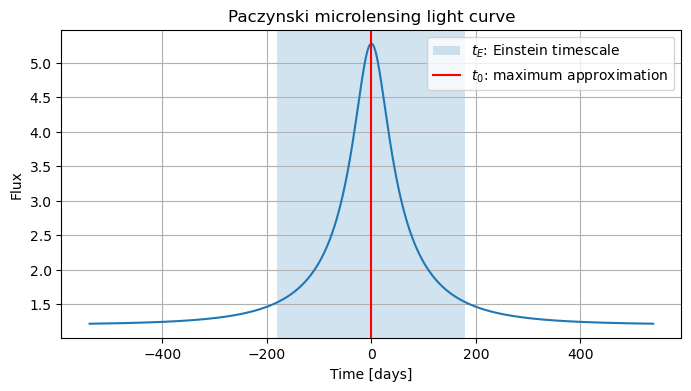

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set microlensing system parameters

lens_mass = 5        # lens mass in solar masses
mu_rel = 2.0           # relative proper motion (mas/yr)
D_L = 6.0e3            # lens distance in pc
D_S = 7.0e3            # source distance in pc
t0 = 0.0               # time of maximum approximation [days]
u0 = 0.2               # minimum impact parameter
F_s = 1.0              # source flux (arbitrary units)
F_b = 0.2              # blend flux

# Convert system parameters into light-curve parameters

import astropy.units as u
import astropy.constants as const

def einstein_angular_radius(M_L, D_L, D_S):
    """
    Inputs:
        M_L: (float) mass in solar masses
        D_L: (float) lens distance in pc
        D_S: (float) source distance in pc

    Returns: (float) theta_E in mas 
    """
    D_L = D_L * u.pc
    D_S = D_S * u.pc
    M_L = M_L * u.M_sun
    C = const.c
    G = const.G
    K = 4 * G / (C**2)
    pi_rel = ((1 / D_L) - (1 / D_S)) * u.rad

    theta_E_rad = np.sqrt(K * pi_rel * M_L)
    return theta_E_rad.to(u.mas, equivalencies=u.dimensionless_angles()).value


def einstein_timescale(theta_E, mu_rel):
    """
    Inputs: 
        theta_E: (float) Einstein radius in mas
        mu_rel: (float) proper motion in mas/year
    Returns: (float) t_E in days
    """
    mu_rel = mu_rel * (u.mas / u.year)
    return (theta_E*u.mas / mu_rel).to(u.day).value

theta_E = einstein_angular_radius(lens_mass, D_L, D_S)  # mas
t_E = einstein_timescale(theta_E, mu_rel)       # days

print(f"Einstein radius (mas): {theta_E:.3f}")
print(f"Einstein timescale (days): {t_E:.1f}")

def magnification(u):
    """Paczynski magnification for a point-source, point-lens."""
    return (u**2 + 2) / (u * np.sqrt(u**2 + 4))

def microlensing_lightcurve(t, t0, u0, t_E, F_s, F_b):
    """Return total flux F(t) = F_s * A(u) + F_b."""
    u = np.sqrt(u0**2 + ((t - t0) / t_E)**2)
    A = magnification(u)
    return F_s * A + F_b

t = np.linspace(-3*t_E, 3*t_E, 500)
F_t = microlensing_lightcurve(t, t0, u0, t_E, F_s, F_b)


plt.figure(figsize=(8,4))
plt.plot(t, F_t)
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.axvspan(t0 - t_E, t0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.axvline(t0, color ="r", label="$t_0$: maximum approximation")
plt.title("Paczynski microlensing light curve")
plt.grid(True)
plt.legend()
plt.show()


## Image-Based Simulations

**Note on blending:**

In analytic models, the blend flux $F_b$ represents extra light from unresolved nearby stars. But when the microlensed source is **injected directly into real images**, blending is **automatic**:

- The image already contains sky background and neighboring stars.  
- The measured flux naturally includes all local contamination.  

Thus, in this simulation we set $F_b = 0 \rightF(t) = F_s\, A(u(t))$ with blending handled by the image itself.



## Insights of steps
1. Sources: AstroDataLab - TRILEGAL-NOIRLab
2. Microlensing system parameters: Genulens
3. microlensing light curve (high cadence, no noise): pyLIMA
4. obtain cadence to create the micronlensing light curve with realistic cadence (yet, without errors)
5. Filters (cuts)
6. Plots and important results
7. Present ulens_lsst

## 1. Sources: LSST's stellar distribution
[AstroDataLab - TRILEGAL-NOIRLab](https://datalab.noirlab.edu/data/lsst-sim) 
The LSST SIM tables contain a large simulation, based on the TRILEGAL code, of the stars to be observed by the Vera C. Rubin Observatory Legacy Survey of Space and Time (LSST). TRILEGAL uses databases of stellar evolutionary tracks, synthetic spectra, and pulsation models, added to simple prescriptions for the stellar density and star formation histories of the main structures of the Galaxy, to generate mock stellar samples through a population synthesis approach.

LSST SIM provides tables containing a complete simulation for single stars in the Milky Way and Magellanic Clouds down to a depth of r=27.5 mag, equivalent to the co-added depth from the Wide-Fast-Deep portion of the LSST survey. LSST SIM also provides a table for a subset of the anticipated binary systems, including interacting ones, as derived with the BinaPSE module of TRILEGAL.


#### Install Data Lab

In [3]:
# To install Data Lab and query using Python un-comment and run the following:
# !pip install --upgrade astro-datalab

#### Query Data Lab's datasets

Here is a function to easy create the query to reatrieve the needed data.

In [4]:
from dl import queryClient as qc

def sky_catalog_query(catalog, columns, regions, conditions=None, language = "sql"):
    """
    Generate a query for astronomical catalogs based on spatial regions and filters.

    Parameters
    ----------
    catalog : str
        Name of the catalog table.
    columns : list of str
        List of column names to select.
    region : tuple
        (ra, dec, radius) in degrees.
    conditions : list of str
        List of additional filter conditions (e.g., 'mag < 20').
    language : str, optional
        Query language: 'sql' (uses q3c_radial_query) or 'adql' (uses CONTAINS + CIRCLE) (default: 'sql').
    """
    ra, dec, radius = region
    if language == "sql":
        # SQL version with q3c_radial_query
        spatial_clause = f"q3c_radial_query(ra, dec, {ra}, {dec}, {radius})"
    elif language == "adql":
        # ADQL version with CONTAINS + CIRCLE
        spatial_clause = f"CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra}, {dec}, {radius}))=1"
    else:
        raise ValueError("language must be 'sql' or 'adql'")

    # Additional conditions
    if conditions is not None:
        filter_part = " AND ".join(conditions)
    if conditions and spatial_clause:
        where_statement = f"({spatial_part}) AND ({filter_part})"
    elif spatial_clause:
        where_statement = spatial_clause
    elif conditions:
        where_statement = filter_part
    else:
        where_statement = "1=1"

    query = f"""
    SELECT {', '.join(columns)}
    FROM {catalog}
    WHERE {where_statement}
    """
    return query

We will query all sources within a radius of 0.5 degrees centered on (62,-34) and selected columns (more details about this dataset columns [here](https://datalab.noirlab.edu/data-explorer?showTable=lsst_sim.simdr2))

In [5]:
catalog = "lsst_sim.simdr2" # "lsst_sim.simdr2_binary"
region = (62, -34, 0.5) # degrees
columns = ["ra", "dec", "logl", "logte", 
           "umag", "gmag", "rmag", "imag", "zmag", "ymag", "gc", "label"]
# condition = 
query = sky_catalog_query(catalog, columns, region,  language="sql")
print(query)
try:
    res = qc.query(sql=query, fmt="table")
    sources = res.to_pandas()
except Exception as e:
    print(str(e))



    SELECT ra, dec, logl, logte, umag, gmag, rmag, imag, zmag, ymag, gc, label
    FROM lsst_sim.simdr2
    WHERE q3c_radial_query(ra, dec, 62, -34, 0.5)
    


#### Analyze results

In [6]:
sources

,ra,dec,logl,logte,umag,gmag,rmag,imag,zmag,ymag,gc,label
0,61.623969,-34.390371,-2.277,3.5828,31.061,28.505,27.199,26.631,26.354,26.205,3,1
1,61.601897,-34.375096,-0.378,3.7581,23.720,22.821,22.425,22.280,22.236,22.225,3,1
2,61.600147,-34.367165,-1.742,3.6344,30.052,28.153,27.232,26.831,26.638,26.534,3,1
3,61.598361,-34.365108,-2.135,3.5312,28.739,25.816,24.401,23.393,22.906,22.687,2,1
4,61.605346,-34.368540,-1.049,3.6648,27.603,25.804,25.010,24.693,24.548,24.464,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...
20552,62.327281,-33.584432,-0.697,3.7139,28.755,27.502,26.939,26.717,26.628,26.585,3,1
20553,62.327096,-33.583170,-0.271,3.7656,28.014,27.080,26.700,26.570,26.536,26.527,3,1
20554,62.331486,-33.584130,-1.311,3.6616,27.631,26.016,25.234,24.893,24.735,24.653,3,1
20555,62.350772,-33.597834,-0.332,3.7666,25.675,24.859,24.495,24.360,24.320,24.312,3,1


To visualize different properties distribution on the sky, set "column" variable to the name of the property of interest.

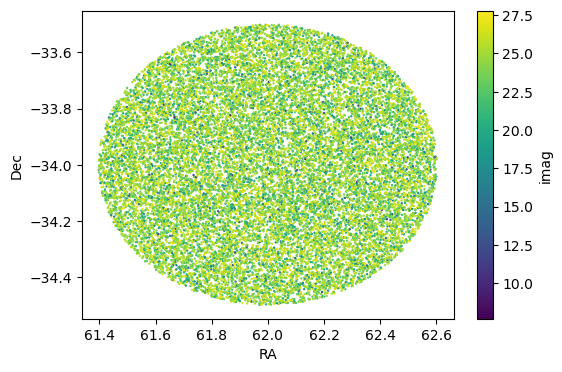

In [7]:
column = "imag"

plt.figure(figsize=(6,4))
sc = plt.scatter(
    sources["ra"],
    sources["dec"],
    s=0.5,
    c=sources[column],   
    cmap="viridis"   
)
plt.xlabel("RA")
plt.ylabel("Dec")

plt.colorbar(sc, label=column)  
plt.show()


* "gc": Galactic component, thin disk=1, thick disk=2, halo=3, bulge=4, MCs=5
* "label": Evolutionary phase, PMS=0, MS=1, SGB=2, RGB=3, CHeB=4,5,6, EAGB=7, TPAGB=8, PAGB+WD=9

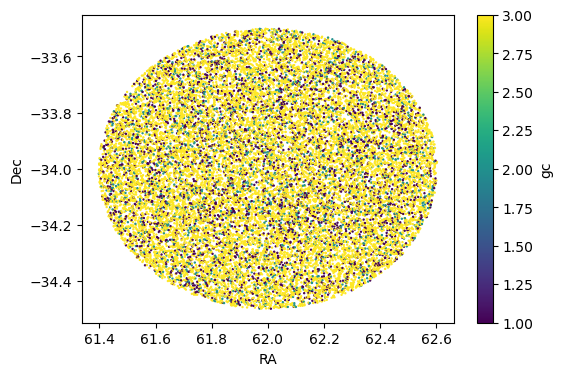

In [8]:
column = "gc"

plt.figure(figsize=(6,4))
sc = plt.scatter(
    sources["ra"],
    sources["dec"],
    s=0.5,
    c=sources[column],   
    cmap="viridis"   
)
plt.xlabel("RA")
plt.ylabel("Dec")

plt.colorbar(sc, label=column)  
plt.show()


In [9]:
sources["gc"].value_counts()

gc
3    15045
1     3405
2     2107
Name: count, dtype: int64

## 2. Microlensing system parameters: Genulens

**Genulens**: Microlensing event distribution simulator

Genulens is a Monte-Carlo tool that generates large samples of **artificial microlensing events** toward the Galactic bulge.  
It uses the Galactic model from **Koshimoto, Baba & Bennett (2021)** and is optimized for fields with  |l| < 10° and |b| < 7°.

Each **row in the Genulens output** corresponds to one possible microlensing event and includes:
- Einstein timescale `t_E`
- Angular Einstein radius `θ_E`
- Microlens parallax vector components
- Lens and source distances
- Proper motions
- Population flags (disk, bulge, NSD)
- A probability weight `wtj` for that event



### Usage

- Generate new distrbution for each sky position in Galactic coordinates:
   ```bash
   ./genulens Nsimu 2e5 l 0.0 b -0.0
- Use a already generated data set for the bulge center with the recommended coordinate limits. |l| < 10° and |b| < 7°.
The ready data set can be download from [this link](https://github.com/nowokaren/ulens_lsst/blob/main/data/chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv) 

In [10]:
import pandas as pd
# set the following as the path to the ready Genlens dataset.
genulens_file_path = "../../data/chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv"
ulens_systems = pd.read_csv(genulens_file_path)

In [11]:
ulens_systems

,wtj,M_L,D_L,D_S,tE,thetaE,piE,piEN,piEE,mu_rel,muSl,muSb,i_L,iS,iL,fREM
0,0.074795,0.654286,3490,5443,80.256400,0.740064,0.138889,0.090923,0.104992,3.368060,-3.070350,-0.904281,99.0,5,6,0
1,0.263890,0.202545,4581,7715,20.187840,0.382484,0.231878,0.201122,0.115401,6.920123,-10.857400,-1.582570,99.0,8,5,0
2,0.087598,0.063387,2758,6055,12.114240,0.319285,0.618506,0.145912,-0.601049,9.626590,-7.132600,-1.007570,99.0,8,7,0
3,0.185654,0.638739,6834,7359,13.420190,0.233110,0.044813,-0.028811,-0.034324,6.344430,-0.918042,-1.961040,99.0,8,8,0
4,0.168014,0.187773,7332,7353,0.924588,0.024819,0.016230,0.007847,0.014207,9.804669,-9.930460,0.936496,99.0,8,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.176847,0.182997,5805,7418,16.047250,0.236304,0.158561,-0.049967,0.150482,5.378501,-5.304220,4.709800,99.0,8,8,0
9996,0.328649,0.551260,7176,7830,24.725300,0.228641,0.050929,-0.050839,0.003031,3.377552,-7.547400,-1.385860,99.0,8,8,0
9997,0.328649,0.116017,5291,7840,18.444030,0.240937,0.255004,0.176783,0.183780,4.771309,-7.380180,2.371210,99.0,8,4,0
9998,0.253492,0.287910,7357,7687,5.139560,0.116918,0.049865,0.049811,-0.002307,8.308941,-9.038590,-5.324530,99.0,8,8,0


The columns needed for this analysis are $D_L$, $D_S$ and $\mu_{rel}$ since others system parameters can be computed or sampled as needed for the particular study case.

**Note: Weights** `wtj`:
* If you are interested on maintain the real distribution of events in the region, you need to random sample the data set taking into account the weights.
* If you just need realistic combination of parameters and want to take into account all possible events in the field of interest, you can just sample uniformly events from the data set.

In this tutorial we are going to do the last one.

In [12]:
cols = ["D_L", "D_S", "mu_rel"]  # minimal 
cols = ["D_L", "D_S", "mu_rel", "piEE", "piEN", "M_L"]  # for this example
ulens_systems = pd.read_csv(genulens_file_path, usecols=cols)

In [13]:
ulens_systems

,M_L,D_L,D_S,piEN,piEE,mu_rel
0,0.654286,3490,5443,0.090923,0.104992,3.368060
1,0.202545,4581,7715,0.201122,0.115401,6.920123
2,0.063387,2758,6055,0.145912,-0.601049,9.626590
3,0.638739,6834,7359,-0.028811,-0.034324,6.344430
4,0.187773,7332,7353,0.007847,0.014207,9.804669
...,...,...,...,...,...,...
9995,0.182997,5805,7418,-0.049967,0.150482,5.378501
9996,0.551260,7176,7830,-0.050839,0.003031,3.377552
9997,0.116017,5291,7840,0.176783,0.183780,4.771309
9998,0.287910,7357,7687,0.049811,-0.002307,8.308941


## 3. LSST cadence

The cadence is set by exposures present in the Data Preview choosen for the simulation. In this example we are going to use **DP0.2** images. 

### Load overlapping exposures with region
First, we need to collect exposure dataIds for those overlapping with the region of interest.

In [14]:
from lsst.daf.butler import Butler
butler = Butler('dp02', collections='2.2i/runs/DP0.2')

In [15]:
bands = "ugrizy"
bands_str = f"({', '.join(map(repr, bands))})"
ra, dec, radius = 62, -34, 0.5

In [16]:
from lsst.geom import Angle, SpherePoint, degrees, Point2D, Extent2I, Point2I, Box2I
from lsst.sphgeom import Region

target_point = SpherePoint(Angle(ra, degrees), Angle(dec, degrees))
RA = target_point.getLongitude().asDegrees()
DEC = target_point.getLatitude().asDegrees()
circle = Region.from_ivoa_pos(f"CIRCLE {RA} {DEC} {radius}")



From the visit_detector_region Table 

In [17]:
n_max = None
datasetRefs = list(
    butler.query_datasets(
        "calexp",
        where=f"visit_detector_region.region OVERLAPS my_region AND band IN {bands_str}",
        bind={"ra": RA, "dec": DEC, "my_region": circle},
        limit=None if n_max is None else n_max,
    )
)
print(f"Found {len(datasetRefs)} calexps.")

Found 11130 calexps.


### Load exposure midpoint time (MJD) 
The next step is to load epochs for each visit for the region of interest

In [18]:
from lsst.rsp import get_tap_service
import os

calexps_data = []
catalog = "CcdVisit"
columns = ["ra", "decl", "expMidptMJD", "detector", "visitId", "psfSigma", "zeroPoint"]
full_catalog = f"dp02_dc2_catalogs.{catalog}"


query = f"""
SELECT {', '.join(columns)}
FROM {full_catalog}
WHERE CONTAINS(
        POINT('ICRS', ra, decl),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
      ) = 1
"""

service = get_tap_service("tap")
job = service.submit_job(query)
job.run()
job.wait(phases=["COMPLETED", "ERROR"])

if job.phase == "ERROR":
    job.raise_if_error()

ccd_visit = job.fetch_result().to_table().to_pandas()

print(f"Records found: {len(ccd_visit)}")

Records found: 6511


In [19]:
ccd_visit

,ra,decl,expMidptMJD,detector,visitId,psfSigma,zeroPoint
0,61.972995,-34.429801,60962.274795,120,944220,1.86519,32.334702
1,61.892295,-34.205009,60962.274795,123,944220,1.86034,32.335201
2,61.620104,-34.270134,60962.274795,124,944220,1.86555,32.334499
3,62.044314,-34.450814,60934.256153,75,921306,1.63991,32.342800
4,61.836594,-34.290639,60934.256153,78,921306,1.63996,32.337898
...,...,...,...,...,...,...,...
6506,62.135145,-33.532218,60653.050949,11,725881,1.69006,31.462500
6507,61.856147,-33.570784,60653.050949,18,725881,1.68888,31.463600
6508,62.097796,-33.531805,60687.171878,161,749704,1.89787,31.460800
6509,62.246889,-33.609964,60753.029111,65,796400,1.61263,31.462900


### Merge exposure Ids with epochs
With calexps refrences (dataId) we can filter its ccd visit data and save the expMidptMJD

In [20]:
calexps_data = []
for ref in datasetRefs:
    detector = ref.dataId["detector"]
    visit = ref.dataId["visit"]
    mask = (ccd_visit["detector"] == detector) & (ccd_visit["visitId"] == visit)
    if mask.any():
        row = ccd_visit[mask].iloc[0]
        data = {
            "detector": detector,
            "visit": visit,
            "band": ref.dataId["band"],
            "expMidptMJD": row["expMidptMJD"],
            "psfSigma": row["psfSigma"],
        }
        calexps_data.append(data)


In [21]:
calexps_data = pd.DataFrame(calexps_data).sort_values("expMidptMJD")
calexps_data

,detector,visit,band,expMidptMJD,psfSigma
662,20,2334,u,59583.120963,1.99418
761,23,2334,u,59583.120963,2.00700
629,19,2334,u,59583.120963,1.99537
5250,150,2338,u,59583.122790,2.01033
5136,147,2338,u,59583.122790,2.00866
...,...,...,...,...,...
661,19,1233922,r,61404.157167,1.68064
760,22,1233922,r,61404.157167,1.67692
794,23,1233922,r,61404.157167,1.67348
726,21,1233922,r,61404.157167,1.67719


In [22]:
epochs_mjd = {
    band: sorted(set(calexps_data[calexps_data["band"] == band]["expMidptMJD"].values))
    for band in bands
}
epochs_mjd =  {k: v for k, v in epochs_mjd.items() if len(v) != 0} # clean from empty bands
epochs_mjd

{'u': [np.float64(59583.1209632),
  np.float64(59583.1227902),
  np.float64(59583.1232392),
  np.float64(59583.1269102),
  np.float64(59819.2927762),
  np.float64(59851.2166012),
  np.float64(59851.2170502),
  np.float64(59877.1229902),
  np.float64(59904.0762212),
  np.float64(59904.0866502),
  np.float64(59905.0642402),
  np.float64(59968.1013572),
  np.float64(60176.3987112),
  np.float64(60198.3260152),
  np.float64(60198.3264642),
  np.float64(60200.2545292),
  np.float64(60236.2286792),
  np.float64(60261.0759832),
  np.float64(60261.0907662),
  np.float64(60261.0925532),
  np.float64(60557.2686752),
  np.float64(60557.2704832),
  np.float64(60557.2781282),
  np.float64(60557.2835022),
  np.float64(60582.2175842),
  np.float64(60613.1367962),
  np.float64(60613.1470422),
  np.float64(60644.0694252),
  np.float64(60878.4012612),
  np.float64(60878.4139852),
  np.float64(60907.3980062),
  np.float64(60911.3146742),
  np.float64(60911.3151232),
  np.float64(60911.3169122),
  np.floa

## 4. Simulate microlensing light curve with pyLIMA

[pyLIMA](https://github.com/ebachelet/pyLIMA) is the first open source software for modeling microlensing events

Un-comment the following line to install pyLIMA

In [23]:
# !pip install -y pyLIMA

pyLIMA works with Julian Dates, so epochs needs to be transformed

In [24]:
epochs_jd = {band: np.array(epochs_mjd[band])+2400000.5 for band in epochs_mjd}
epochs_jd

{'u': array([2459583.6209632, 2459583.6227902, 2459583.6232392, 2459583.6269102,
        2459819.7927762, 2459851.7166012, 2459851.7170502, 2459877.6229902,
        2459904.5762212, 2459904.5866502, 2459905.5642402, 2459968.6013572,
        2460176.8987112, 2460198.8260152, 2460198.8264642, 2460200.7545292,
        2460236.7286792, 2460261.5759832, 2460261.5907662, 2460261.5925532,
        2460557.7686752, 2460557.7704832, 2460557.7781282, 2460557.7835022,
        2460582.7175842, 2460613.6367962, 2460613.6470422, 2460644.5694252,
        2460878.9012612, 2460878.9139852, 2460907.8980062, 2460911.8146742,
        2460911.8151232, 2460911.8169122, 2460911.8178122, 2460966.6691772,
        2460966.6696252, 2460970.6822402, 2460971.6292022, 2460971.6735002,
        2460996.5922202, 2460996.6052982, 2461297.7430672, 2461297.7708702,
        2461297.7753602, 2461297.7762622, 2461320.7037982, 2461320.7073802,
        2461320.7078292, 2461321.6967622, 2461322.6750072, 2461322.6759022,
       

In [25]:
# to compare Ideal high cadence light curve with Ideal LSST cadence light curve
survey_dates = (min(min(v) for v in epochs_jd.values()), max(max(v) for v in epochs_jd.values()) )
epochs_ideal = {band: np.linspace(survey_dates[0], survey_dates[1], 10000) for band in bands}

In [44]:
calexps_data.head(None)

,detector,visit,band,expMidptMJD,psfSigma
1464,173,2338,u,59583.122790,2.01235
1270,150,2338,u,59583.122790,2.01033
1205,143,2338,u,59583.122790,2.00933
1526,180,2338,u,59583.122790,2.00625
275,34,2347,u,59583.126910,2.10051
...,...,...,...,...,...
728,84,1231940,i,61394.178948,1.41359
1575,185,1231941,i,61394.179396,1.40463
1593,188,1231941,i,61394.179396,1.40926
163,20,1233922,r,61404.157167,1.67791


Define functions to transform system microlesing parameters to light curve microlesing paramters (i.e. pyLIMA parameters)

In [26]:
import numpy as np
import copy
import matplotlib.pyplot as plt
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
import numpy as np
import astropy.units as u
from astropy.constants import G, c, M_sun, L_sun, sigma_sb

ZP = {
    "u": 27.03,
    "g": 28.38,
    "r": 28.16,
    "i": 27.85,
    "z": 27.46,
    "y": 26.68
}

COLOR_FILTER = {
    "u": "b",
    "g": "c",
    "r": "g",
    "i": "orange",
    "z": "r",
    "y": "m"
}

def simulate_microlensing(
    epochs: dict,          # Dict of np arrays: {band: times_JD}
    mags: dict,            # Dict: {band: baseline_mag}
    ra: float,             # Right ascension in degrees
    dec: float,            # Declination in degrees
    params: dict,          # Model params: {'t0': ..., 'u0': ..., 'tE': ..., optional 'piEN', 'piEE', etc.}
    model_type: str = 'PSPL',  # Model: 'PSPL', 'FSPL', 'USBL', etc.
    parallax: bool = False,    # Include parallax?
    g: float = 0.0,        # Blending factor
    event_name: str = 'ulens', # Event name
    event_id: int = 0      # Seed for random
):
    """
    Simulate microlensing light curve using pyLIMA.
    
    To switch models:
    - PSPL: Base params ('t0', 'u0', 'tE')
    - FSPL: Add 'rho'
    - USBL: Add 'rho', 's', 'q', 'alpha'
    - For parallax: Add 'piEN', 'piEE'
    - Extend by importing new model and adding elif block.
    
    Returns: (magnitudes dict, magnification dict)
    """
    # Create pyLIMA event
    my_event = event.Event(ra=ra, dec=dec)
    my_event.name = event_name
    
    # Add telescopes for each band
    bands = list(epochs.keys())
    for band in bands:
        # Dummy mag/err for simulation (will be overwritten)
        ts = np.column_stack((epochs[band], np.ones(len(epochs[band])) * 20, np.ones(len(epochs[band])) * 20)).astype(float)
        tel = telescopes.Telescope(
            name=band,
            camera_filter=band,
            location="Earth",
            lightcurve=ts,
            lightcurve_names=["time", "mag", "err_mag"],
            lightcurve_units=["JD", "mag", "mag"]
        )
        my_event.telescopes.append(tel)
    
    new_event = copy.deepcopy(my_event)
    np.random.seed(event_id)
    
    # Parallax setup
    parallax_model = ["Full", params['t0']] if parallax else ["None", 0.0]
    
    # Instantiate model 
    if model_type == 'PSPL':
        from pyLIMA.models import PSPL_model
        my_model = PSPL_model.PSPLmodel(new_event, parallax=parallax_model)
    elif model_type == 'FSPL':
        from pyLIMA.models import FSPLarge_model
        my_model = FSPLarge_model.FSPLargemodel(new_event, parallax=parallax_model)
    elif model_type == 'USBL':
        from pyLIMA.models import USBL_model
        choice = np.random.choice(["central_caustic", "second_caustic", "third_caustic"])
        my_model = USBL_model.USBLmodel(new_event, origin=[choice, [0, 0]], 
                                        parallax=parallax_model, blend_flux_parameter="ftotal")
    else:
        raise ValueError(f"Unknown model: {model_type}")
    
    # Prepare parameters 
    model_params = {k: v for k, v in params.items() if (parallax or k not in ['piEN', 'piEE'])}
    my_parameters = list(model_params.values())
    
    # Add flux parameters for each telescope
    my_flux_parameters = []
    for telescope in new_event.telescopes:
        band = telescope.name
        flux_baseline = 10 ** ((ZP[band] - mags[band]) / 2.5)
        f_source = flux_baseline / (1 + g)
        f_total = f_source * (1 + g)
        # Adjust based on blend_flux_parameter (ftotal or g)
        if my_model.blend_flux_parameter == "ftotal":
            my_flux_parameters.extend([f_source, f_total])
        else:
            my_flux_parameters.extend([f_source, f_source * g])
    
    my_parameters += my_flux_parameters
    pyLIMA_params = my_model.compute_pyLIMA_parameters(my_parameters)
    
    # Simulate light curve without noise
    simulator.simulate_lightcurve(my_model, pyLIMA_params, add_noise=False)
    
    # Compute magnification and update light curves
    magnitudes = {}
    magnifications = {}
    for telescope in my_model.event.telescopes:
        mag = my_model.model_magnification(telescope, pyLIMA_params)
        flux = my_model.compute_the_microlensing_model(telescope, pyLIMA_params)["photometry"]
        telescope.lightcurve["magnification"] = mag
        telescope.lightcurve["flux"] = flux
        telescope.lightcurve["mag"] = ZP[telescope.name] - 2.5 * np.log10(np.abs(flux))
        magnitudes[telescope.name] = telescope.lightcurve["mag"].value
        magnifications[telescope.name] = mag
    
    return magnitudes, magnifications, pyLIMA_params


def einstein_angular_radius(M_L, D_L, D_S):
    """
    M_L: float [Msun]
    D_L, D_S: float [pc]
    Returns θ_E in mas
    """
    M_L = M_L * u.M_sun
    D_L = D_L * u.pc
    D_S = D_S * u.pc
    pi_rel = (1/D_L - 1/D_S) * u.rad  

    theta_E = np.sqrt( (4*G*M_L/c**2) * pi_rel )

    return theta_E.to(u.mas, equivalencies=u.dimensionless_angles()).value

def einstein_timescale(theta_E, mu_rel):
    """
    theta_E: mas
    mu_rel: mas/yr
    Returns t_E in days
    """
    theta_E = theta_E * u.mas
    mu_rel = mu_rel * (u.mas/u.yr)

    tE = (theta_E / mu_rel).to(u.day)
    return tE.value


def norm_source_radius(logL, logTe, D_L, D_S, M_L):
    """
    Compute rho = theta_* / theta_E
    """
    # Stellar (source) physical radius
    L_star = (10**logL) * L_sun
    T_eff  = (10**logTe) * u.K

    R = np.sqrt(L_star / (4*np.pi*sigma_sb*T_eff**4))

    # Angular radius of the source
    theta_s = (R / (D_S * u.pc)).to(u.mas, equivalencies=u.dimensionless_angles())

    # Einstein radius 
    theta_E = einstein_angular_radius(M_L, D_L, D_S) * u.mas

    return (theta_s / theta_E).value


def norm_separation(D_L, semi_major_axis, theta_E):
    """
    D_L in pc, semi_major_axis in AU, θ_E in mas
    """
    D_L = D_L * u.pc
    a = semi_major_axis * u.au

    s_ang = (a/D_L).to(u.mas, equivalencies=u.dimensionless_angles())
    return (s_ang / (theta_E * u.mas)).value


#### Microlensing parameters 
Obtain geometry and properties of source and lens: **system parameters**. 

In [27]:
import numpy as np
import copy
from pyLIMA import event, telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.simulations import simulator

name = "ulens"

ZP={"u": 27.03,
    "g": 28.38,
    "r": 28.16,
    "i": 27.85,
    "z": 27.46,
    "y": 26.68}

src = sources.iloc[1241]
ra = float(src["ra"])
dec = float(src["dec"])
logL = float(src["logl"])
logTe = float(src["logte"])

mags = {
    "u": float(src["umag"]),
    "g": float(src["gmag"]),
    "r": float(src["rmag"]),
    "i": float(src["imag"]),
    "z": float(src["zmag"]),
    "y": float(src["ymag"]),
}

lens = ulens_systems.iloc[3213]
M_L = float(lens["M_L"])     # Msun
D_L = float(lens["D_L"])     # pc
D_S = float(lens["D_S"])     # pc
mu_rel = float(lens["mu_rel"])  # mas/yr
piEN = float(lens.get("piEN", 0.0))
piEE = float(lens.get("piEE", 0.0))


event_id = 0
g = 0.0  # No blending since it comes naturally from image-based simulation

Now, we can transform them to **pyLIMA parameters**

In [28]:
theta_E = einstein_angular_radius(M_L, D_L, D_S)   # mas
t_E     = einstein_timescale(theta_E, mu_rel)      # days
t_0     = np.median(epochs_jd["i"])
rho     = norm_source_radius(logL, logTe, D_L, D_S, M_L)
u0      = rho * 0.01

print("Microlensing Parameters")
print("-" * 40)
print(f"Einstein radius       θ_E  = {theta_E:>10.4f} mas")
print(f"Einstein timescale    t_E  = {t_E:>10.4f} days")
print(f"Event time            t_0  = {t_0:>10.4f} JD")
print(f"Source radius ratio   ρ    = {rho:>10}")
print(f"Impact parameter      u₀   = {u0:>10}")
print("-" * 40)


Microlensing Parameters
----------------------------------------
Einstein radius       θ_E  =     2.1950 mas
Einstein timescale    t_E  =   219.1926 days
Event time            t_0  = 2460603.8515 JD
Source radius ratio   ρ    = 4.941909334620559e-06
Impact parameter      u₀   = 4.941909334620559e-08
----------------------------------------


#### Point Source Point Lens

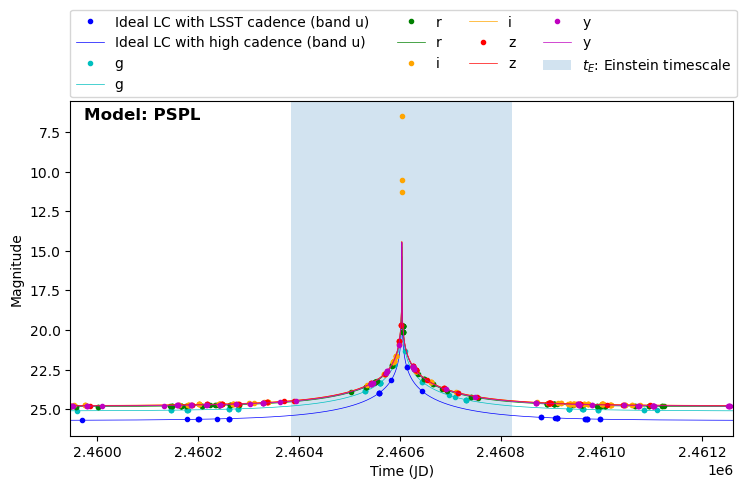

OrderedDict([('t0', np.float64(2460603.8515182)),
             ('u0', np.float64(4.941909334620559e-08)),
             ('tE', np.float64(219.1925636041397)),
             ('fsource_u', 3.407218616593571),
             ('ftotal_u', 3.407218616593571),
             ('fsource_g', 20.473872763416374),
             ('ftotal_g', 20.473872763416374),
             ('fsource_r', 21.242224773887003),
             ('ftotal_r', 21.242224773887003),
             ('fsource_i', 17.108029875993314),
             ('ftotal_i', 17.108029875993314),
             ('fsource_z', 11.87955027941653),
             ('ftotal_z', 11.87955027941653),
             ('fsource_y', 5.6337815085093785),
             ('ftotal_y', 5.6337815085093785),
             ('fblend_u', 0.0),
             ('gblend_u', 0.0),
             ('fblend_g', 0.0),
             ('gblend_g', 0.0),
             ('fblend_r', 0.0),
             ('gblend_r', 0.0),
             ('fblend_i', 0.0),
             ('gblend_i', 0.0),
             ('fblen

In [29]:

params_pspl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E
}

magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: PSPL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
plt.xlim(t_0-t_E*3, t_0+t_E*3)
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()

pyLIMA_params

#### Finite Source Point Lens

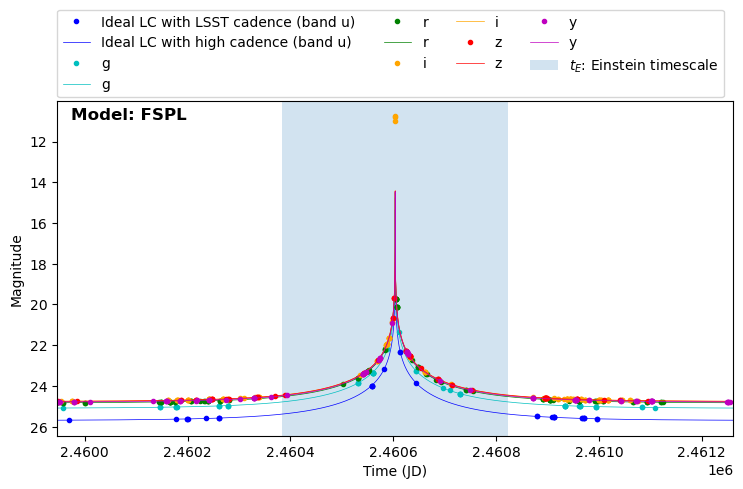

OrderedDict([('t0', np.float64(2460603.8515182)),
             ('u0', np.float64(4.941909334620559e-08)),
             ('tE', np.float64(219.1925636041397)),
             ('rho', np.float64(4.941909334620559e-06)),
             ('fsource_u', 3.407218616593571),
             ('ftotal_u', 3.407218616593571),
             ('fsource_g', 20.473872763416374),
             ('ftotal_g', 20.473872763416374),
             ('fsource_r', 21.242224773887003),
             ('ftotal_r', 21.242224773887003),
             ('fsource_i', 17.108029875993314),
             ('ftotal_i', 17.108029875993314),
             ('fsource_z', 11.87955027941653),
             ('ftotal_z', 11.87955027941653),
             ('fsource_y', 5.6337815085093785),
             ('ftotal_y', 5.6337815085093785),
             ('fblend_u', 0.0),
             ('gblend_u', 0.0),
             ('fblend_g', 0.0),
             ('gblend_g', 0.0),
             ('fblend_r', 0.0),
             ('gblend_r', 0.0),
             ('fblend_i', 0

In [30]:
import numpy as np
import astropy.units as u
import astropy.constants as const

theta_E = einstein_angular_radius(M_L, D_L, D_S)  # mas
tE = einstein_timescale(theta_E, mu_rel)      # days


params_fspl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E,
    "rho": rho
}

magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_fspl, model_type='FSPL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_fspl, model_type='FSPL', parallax=False
)


plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: FSPL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
plt.xlim(t_0-t_E*3, t_0+t_E*3)
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()

pyLIMA_params

#### Binary system

s=np.float64(2.219883610492184)
q=0.5
alpha=2.246833659321132


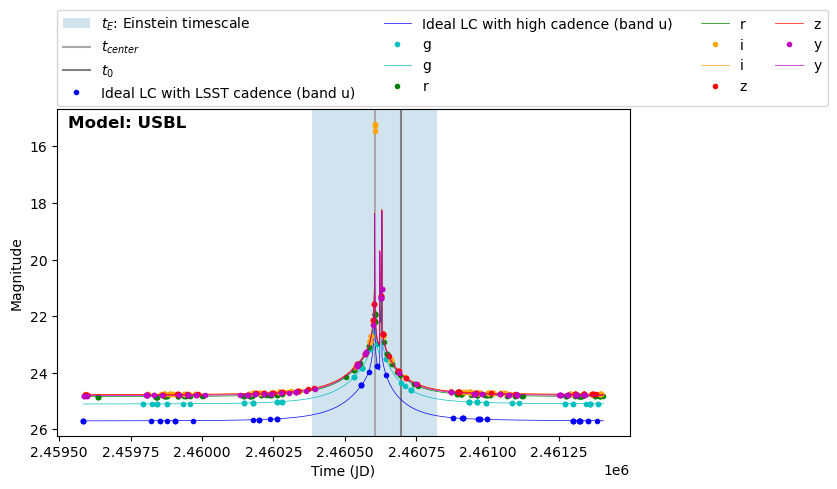

OrderedDict([('t_center', np.float64(2460603.8515182)),
             ('u_center', np.float64(4.941909334620559e-08)),
             ('tE', np.float64(219.1925636041397)),
             ('rho', np.float64(4.941909334620559e-06)),
             ('separation', np.float64(2.219883610492184)),
             ('mass_ratio', 0.5),
             ('alpha', 2.246833659321132),
             ('fsource_u', 3.407218616593571),
             ('ftotal_u', 3.407218616593571),
             ('fsource_g', 20.473872763416374),
             ('ftotal_g', 20.473872763416374),
             ('fsource_r', 21.242224773887003),
             ('ftotal_r', 21.242224773887003),
             ('fsource_i', 17.108029875993314),
             ('ftotal_i', 17.108029875993314),
             ('fsource_z', 11.87955027941653),
             ('ftotal_z', 11.87955027941653),
             ('fsource_y', 5.6337815085093785),
             ('ftotal_y', 5.6337815085093785),
             ('t0', 2460694.4378870814),
             ('u0', -0.515220

In [31]:
semi_major_axis = np.random.uniform(0.1, 28) 
s = norm_separation(D_L, semi_major_axis, theta_E)
print(f"{s=}")
M_L2 = 0.00095  # approx a planet with Jupyter mass in solar units
M_L2 = M_L/2  # another star with half mass
q = M_L2/M_L
print(f"{q=}")
alpha = np.random.uniform(0, np.pi)
print(f"{alpha=}")

params_usbl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E,
    "rho": rho,
    's': s,          # Normalized separation
    'q': q,          # Mass ratio
    'alpha': alpha   # Trajectory angle (radians)

}


magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_usbl, model_type='USBL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_usbl, model_type='USBL', parallax=False
)

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: USBL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.axvline(pyLIMA_params["t_center"], color="darkgray", label="$t_{center}$")
plt.axvline(pyLIMA_params["t0"], color="gray", label="$t_{0}$")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
# plt.xlim(t_0-t_E*3, t_0+t_E*3)

plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()

pyLIMA_params

# ulens_lsst: A pipeline to simulate LSST-like light curves at image-level
Run an image-based simulation of microlensing LSST-like light curve.

First, we define the region to inject to random sample N events to be injected. In this example we are going to inject only one event)

In [32]:
region = (62, -34, 0.1) # degrees

### Microlensing parameters

In [33]:
catalog = "lsst_sim.simdr2" # "lsst_sim.simdr2_binary"
columns = ["ra", "dec", "logl", "logte", 
           "umag", "gmag", "rmag", "imag", "zmag", "ymag", "gc", "label"]
# condition = 
query = sky_catalog_query(catalog, columns, region,  language="sql")
print(query)
try:
    res = qc.query(sql=query, fmt="table")
    sources = res.to_pandas()
except Exception as e:
    print(str(e))



    SELECT ra, dec, logl, logte, umag, gmag, rmag, imag, zmag, ymag, gc, label
    FROM lsst_sim.simdr2
    WHERE q3c_radial_query(ra, dec, 62, -34, 0.1)
    


In [34]:
ulens_systems

,M_L,D_L,D_S,piEN,piEE,mu_rel
0,0.654286,3490,5443,0.090923,0.104992,3.368060
1,0.202545,4581,7715,0.201122,0.115401,6.920123
2,0.063387,2758,6055,0.145912,-0.601049,9.626590
3,0.638739,6834,7359,-0.028811,-0.034324,6.344430
4,0.187773,7332,7353,0.007847,0.014207,9.804669
...,...,...,...,...,...,...
9995,0.182997,5805,7418,-0.049967,0.150482,5.378501
9996,0.551260,7176,7830,-0.050839,0.003031,3.377552
9997,0.116017,5291,7840,0.176783,0.183780,4.771309
9998,0.287910,7357,7687,0.049811,-0.002307,8.308941


### Load exposures overlapping region
We need LSST cadence to simulate the ideal light curve

In [35]:
from lsst.geom import Angle, SpherePoint, degrees, Point2D, Extent2I, Point2I, Box2I
from lsst.sphgeom import Region

ra, dec, radius = region
target_point = SpherePoint(Angle(ra, degrees), Angle(dec, degrees))
RA = target_point.getLongitude().asDegrees()
DEC = target_point.getLatitude().asDegrees()
circle = Region.from_ivoa_pos(f"CIRCLE {RA} {DEC} {radius}")
n_max = None
datasetRefs = list(
    butler.query_datasets(
        "calexp",
        where=f"visit_detector_region.region OVERLAPS my_region AND band IN {bands_str}",
        bind={"ra": RA, "dec": DEC, "my_region": circle},
        limit=None if n_max is None else n_max,
    )
)
print(f"Found {len(datasetRefs)} calexps.")
from lsst.rsp import get_tap_service
import os

calexps_data = []
catalog = "CcdVisit"
columns = ["ra", "decl", "expMidptMJD", "detector", "visitId", "psfSigma", "zeroPoint"]
full_catalog = f"dp02_dc2_catalogs.{catalog}"

delta_radius = 0.2  
# since we can search ccd visits by its CENTER location, but our region can intersect 
# the calexp in its edge, we need to increase the search radius by at least a half (or the diagonal)
# of  calexp. (So the output dataset for this search must be larger than calexps found for the region
# to be injected)


query = f"""
SELECT {', '.join(columns)}
FROM {full_catalog}
WHERE CONTAINS(
        POINT('ICRS', ra, decl),
        CIRCLE('ICRS', {ra}, {dec}, {radius + delta_radius})
      ) = 1
"""

service = get_tap_service("tap")
job = service.submit_job(query)
job.run()
job.wait(phases=["COMPLETED", "ERROR"])

if job.phase == "ERROR":
    job.raise_if_error()

ccd_visit = job.fetch_result().to_table().to_pandas()

print(f"CCdVisit records found: {len(ccd_visit)}")
calexps_data = []
for ref in datasetRefs:
    detector = ref.dataId["detector"]
    visit = ref.dataId["visit"]
    mask = (ccd_visit["detector"] == detector) & (ccd_visit["visitId"] == visit)
    if mask.any():
        row = ccd_visit[mask].iloc[0]
        data = {
            "detector": detector,
            "visit": visit,
            "band": ref.dataId["band"],
            "expMidptMJD": row["expMidptMJD"],
            "psfSigma": row["psfSigma"],
        }
        calexps_data.append(data)

calexps_data = pd.DataFrame(calexps_data).sort_values("expMidptMJD")
len(calexps_data)

Found 1594 calexps.
CCdVisit records found: 2361


1594

In [36]:
epochs_mjd = {
    band: sorted(set(calexps_data[calexps_data["band"] == band]["expMidptMJD"].values))
    for band in bands
}
epochs_mjd =  {k: v for k, v in epochs_mjd.items() if len(v) != 0} # clean from empty bands
epoch_idx = {                                           # to easy find the magnitudes after simulation
    b: {m: i for i, m in enumerate(epochs_mjd[b])}
    for b in bands
}
epochs_jd = {band: np.array(epochs_mjd[band])+2400000.5 for band in epochs_mjd}
survey_dates = (min(min(v) for v in epochs_jd.values()), max(max(v) for v in epochs_jd.values()) )
epochs_ideal = {band: np.linspace(survey_dates[0], survey_dates[1], 10000) for band in bands}

### Simulate ideal light curve with LSST cadence

In [37]:
src = sources.iloc[124]
ra = float(src["ra"])
dec = float(src["dec"])
logL = float(src["logl"])
logTe = float(src["logte"])

mags = {
    "u": float(src["umag"]),
    "g": float(src["gmag"]),
    "r": float(src["rmag"]),
    "i": float(src["imag"]),
    "z": float(src["zmag"]),
    "y": float(src["ymag"]),
}

lens = ulens_systems.iloc[3213]
M_L = float(lens["M_L"])     # Msun
D_L = float(lens["D_L"])     # pc
D_S = float(lens["D_S"])     # pc
mu_rel = float(lens["mu_rel"])  # mas/yr

event_id = 0
g = 0.0  # No blending since it comes naturally from image-based simulation
theta_E = einstein_angular_radius(M_L, D_L, D_S)   # mas
t_E     = einstein_timescale(theta_E, mu_rel)      # days
t_0     = np.median(epochs_jd["i"])
u0      =  0.1

print("Microlensing Parameters")
print("-" * 40)
print(f"Einstein radius       θ_E  = {theta_E:>10.4f} mas")
print(f"Einstein timescale    t_E  = {t_E:>10.4f} days")
print(f"Event time            t_0  = {t_0:>10.4f} JD")
print(f"Impact parameter      u₀   = {u0:>10}")
print("-" * 40)


Microlensing Parameters
----------------------------------------
Einstein radius       θ_E  =     2.1950 mas
Einstein timescale    t_E  =   219.1926 days
Event time            t_0  = 2460632.6369 JD
Impact parameter      u₀   =        0.1
----------------------------------------


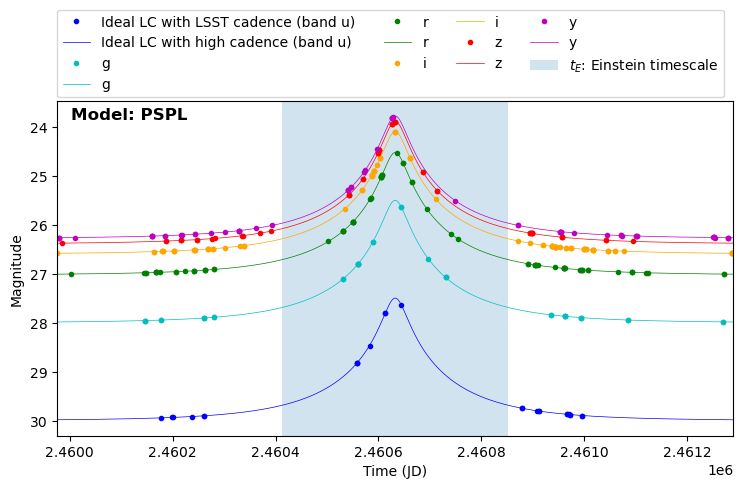

In [38]:
params_pspl = {
    "t0": t_0,
    "u0": u0,
    "tE": t_E
}

magnitudes, magnifications, pyLIMA_params = simulate_microlensing(
    epochs_jd, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)
magnitudes_ideal, magnifications_ideal, pyLIMA_params = simulate_microlensing(
    epochs_ideal, mags, ra, dec, params_pspl, model_type='PSPL', parallax=False
)

plt.figure(figsize=(8,5))
ax = plt.gca()
ax.text(0.02, 0.98, "Model: PSPL", transform=ax.transAxes, ha="left", va="top", 
        fontsize=12, fontweight="bold")
for band in epochs_jd:
    plt.plot(epochs_jd[band], magnitudes[band], ".", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with LSST cadence (band {band})" if band=="u" else band)
    plt.plot(epochs_ideal[band], magnitudes_ideal[band], "-", lw=0.5, color=COLOR_FILTER[band], 
             label=f"Ideal LC with high cadence (band {band})" if band=="u" else band)
    #plt.axhline(mags[band], ls="--", color=COLOR_FILTER[band])
plt.gca().invert_yaxis()
plt.xlabel("Time (JD)")
plt.ylabel("Magnitude")
plt.xlim(t_0-t_E*3, t_0+t_E*3)
plt.axvspan(t_0 - t_E, t_0 + t_E, alpha=0.2, label = "$t_E$: Einstein timescale")
plt.legend(loc = (0.0, 1.01), ncols = 4)
plt.tight_layout()
plt.show()


### Loop over exposures to inject sources

In [39]:
from lsst.source.injection import VisitInjectConfig, VisitInjectTask
from astropy.table import Table
import lsst.geom as geom 

inject_config = VisitInjectConfig(process_all_data_ids=True)
injection_task = VisitInjectTask(config=inject_config)

import lsst.afw.table as afwTable
from lsst.meas.base import ForcedMeasurementTask

schema = afwTable.SourceTable.makeMinimalSchema()
alias = schema.getAliasMap() 
x_key = schema.addField("centroid_x", type="D")
y_key = schema.addField("centroid_y", type="D")
alias.set("slot_Centroid", "centroid")

xx_key = schema.addField("shape_xx", type="D")
yy_key = schema.addField("shape_yy", type="D")
xy_key = schema.addField("shape_xy", type="D")
alias.set("slot_Shape", "shape")
type_key = schema.addField("type_flag", type="F")
config = ForcedMeasurementTask.ConfigClass()
config.copyColumns = {}
config.plugins.names = [
    "base_TransformedCentroid",
    "base_PsfFlux",
    "base_TransformedShape"
]
config.doReplaceWithNoise = False
forcedMeasurementTask = ForcedMeasurementTask(schema, config=config)
del config

def pix_to_sky(exposure, x, y):
    """Convert pixel coordinates to RA and Dec."""
    sphere_point = exposure.wcs.pixelToSky(geom.Point2D(x, y))
    return sphere_point.getRa().asDegrees(), sphere_point.getDec().asDegrees()

def sky_to_pix(exposure, ra, dec):
    """Convert RA and Dec to pixel coordinates."""
    xy = exposure.wcs.skyToPixel(geom.SpherePoint(ra * geom.degrees, dec * geom.degrees))
    return int(np.round(xy.getX())), int(np.round(xy.getY()))

def flux_to_mag(exposure, flux, flux_err):
    photoCalib = exposure.getPhotoCalib()
    measure = photoCalib.instFluxToMagnitude(flux, flux_err)
    return measure.value, measure.error

In [40]:
n_points = 1
ra_values, dec_values = [ra], [dec]
datasetType = 'calexp'

photometry = pd.DataFrame({"timeMJD":[], "band":[], "meas_mag":[], "meas_mag_err":[], 
                           "meas_flux":[], "meas_flux_err":[], "injected_mag":[],
                          "injection_flag":[], "measure_flag":[]})
for i, (idx, calexp_data) in enumerate(calexps_data.iterrows()):
    calexp_photo = {}
    dataId = {'visit': calexp_data["visit"], 'detector': calexp_data["detector"]}
    calexp = butler.get(datasetType, dataId=dataId)
    band = calexp_data["band"]
    mjd  = calexp_data["expMidptMJD"]
    idx_ep = epoch_idx[band][mjd]
    mag = magnitudes[band][idx_ep]
    
    calexp_photo["timeMJD"] = mjd
    calexp_photo["band"] = band
    calexp_photo["injected_mag"] = mag
    if calexp.containsSkyCoords(ra*u.deg, dec*u.deg):
        # Create injection table (with only one event in this case)
        injection_id = list(range(n_points))
        source_type = ["Star"] * n_points
        data = [injection_id, ra_values, dec_values, source_type, [mag]]
        inject_table = Table(data, names=['injection_id', 'ra', 'dec', 'source_type', 'mag'])
    
        # Run injection task
        injected_output = injection_task.run(
            injection_catalogs=[inject_table],
            input_exposure=calexp.clone(),
            psf=calexp.getPsf(),
            photo_calib=calexp.getPhotoCalib(),
            wcs=calexp.wcs
        )
        
        injected_exposure = injected_output.output_exposure
        injected_catalog = injected_output.output_catalog
        
        if injected_catalog["injection_flag"]!=0:
                break
    else:
        calexp_photo


    
    # break 1 51.23

KeyboardInterrupt: 

In [41]:
import numpy as np

n_points = 1
ra_values, dec_values = [ra], [dec]
datasetType = 'calexp'

photometry = pd.DataFrame({
    "overlap":[], "timeMJD":[], "band":[], "meas_mag":[], 
    "meas_mag_err":[], "meas_flux":[], "meas_flux_err":[], 
    "injected_mag":[], "injection_flag":[], "measure_flag":[]
})

for i, (idx, calexp_data) in enumerate(calexps_data.iterrows()):
    calexp_photo = {}
    dataId = {'visit': calexp_data["visit"], 'detector': calexp_data["detector"]}
    calexp = butler.get(datasetType, dataId=dataId)
    band = calexp_data["band"]
    mjd  = calexp_data["expMidptMJD"]
    idx_ep = epoch_idx[band][mjd]
    mag = magnitudes[band][idx_ep]

    calexp_photo["timeMJD"] = mjd
    calexp_photo["band"] = band
    calexp_photo["injected_mag"] = mag

    calexp_photo["meas_mag"] = np.nan
    calexp_photo["meas_mag_err"] = np.nan
    calexp_photo["meas_flux"] = np.nan
    calexp_photo["meas_flux_err"] = np.nan
    calexp_photo["injection_flag"] = np.nan
    calexp_photo["measure_flag"] = np.nan   
    calexp_photo["overlap"] = calexp.containsSkyCoords(ra*u.deg, dec*u.deg)[0]
    if calexp_photo["overlap"]:
        # Inject
        injection_id = list(range(n_points))
        source_type = ["Star"] * n_points
        data = [injection_id, ra_values, dec_values, source_type, [mag]]
        inject_table = Table(data, names=['injection_id', 'ra', 'dec', 'source_type', 'mag'])

        injected_output = injection_task.run(
            injection_catalogs=[inject_table],
            input_exposure=calexp.clone(),
            psf=calexp.getPsf(),
            photo_calib=calexp.getPhotoCalib(),
            wcs=calexp.wcs
        )

        injected_exposure = injected_output.output_exposure
        injected_catalog = injected_output.output_catalog
        calexp_photo["injection_flag"] = injected_catalog["injection_flag"][0]

            
        if len(injected_catalog) > 0:
            
            # Forced Measurement
            forcedSource = afwTable.SourceCatalog(schema)
            for source in injected_catalog:
                sourceRec = forcedSource.addNew()
                coord = geom.SpherePoint(geom.Angle(source["ra"], geom.degrees).asRadians(),geom.Angle(source["dec"], geom.degrees).asRadians(), geom.radians)
                sourceRec.setCoord(coord)
                sourceRec[x_key], sourceRec[y_key]= sky_to_pix(injected_exposure, source["ra"], source["dec"])
                sourceRec[type_key] = 0
            del sourceRec, coord
            forcedMeasCat = forcedMeasurementTask.generateMeasCat(
                injected_exposure, forcedSource, injected_exposure.getWcs()
            )
            forcedMeasurementTask.run(
                forcedMeasCat, injected_exposure, forcedSource, injected_exposure.getWcs()
            )

            # Transform flux to mag 
            tab = forcedMeasCat.asAstropy()
            flux     = tab["base_PsfFlux_instFlux"].value
            flux_err = tab["base_PsfFlux_instFluxErr"].value
            m, m_err = zip(*(flux_to_mag(injected_exposure, f, e) for f, e in zip(flux, flux_err)))

            # Save
            calexp_photo["meas_mag"] = m
            calexp_photo["meas_mag_err"] = m_err
            calexp_photo["meas_flux"] = flux
            calexp_photo["meas_flux_err"] = flux_err
            calexp_photo["measure_flag"] = 1 if tab["base_PsfFlux_flag"][0] else 0


    photometry = pd.concat([photometry, pd.DataFrame([calexp_photo])], ignore_index=True)

# 1h 49m 24s